# 12. 개폐업 데이터 첫 탐색: 30일 만에 닫는 가게들의 정체



## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 만든 노트북 | 출력 |
|---|---|---|
| `bizreg.parquet` (강남구 + 춘천시 사업장 원장) | 01 (13장) | 그래프와 표 (노트북 안). 저장하는 파일 없음 |
| `bizreg_month.parquet` (서울 25구 + 강원 18시군 월별 건수) | 01 (13-5) | |

## 결과 요약
1. **월별 폐업을 그렸더니 춘천 2025년 9 ~ 10월에 봉우리가 있다.** 평년 60 ~ 90건인데 149건, 191건이다. 폭염 여름이 끝난 직후라 "이게 폭염 효과인가" 싶은 모양이다.
2. **영업 기간을 봤더니 0 ~ 30일에 큰 봉우리가 있다.** 2025년 폐업 기록의 **강남 38%, 춘천 31%** 가 개업 30일 안에 닫힌 것이다. 가게가 한 달 만에 망하는 일은 이렇게 흔하지 않다.
3. **정체는 한시적 영업신고였다.** 같은 주소에서 수십 개가 같은 날 열고 같은 날 닫는다. 이름 끝에 `(한시적)`이 붙어 있고, 주소는 코엑스와 백화점, 춘천 축제장이다. 행사 부스와 팝업스토어다.
4. **이 기록을 빼면 춘천의 봉우리가 사라진다.** 191건 -> 71건으로 평년 수준이 된다. 2025년 10월 기록의 **63%** 가 축제 노점이었다.
5. **그래서 이 자료로 폐업을 셀 때는 개업 30일 안에 닫힌 기록을 먼저 빼야 한다.** 이 한 줄이 이 노트북의 결론이고, 11번은 이것을 전제로 시작한다.

## 0. 준비

### 0-1. 라이브러리

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
plt.rc('figure', figsize=(12, 4), dpi=110)

REGIONS = ['강남', '춘천']
REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}
pd.set_option('display.float_format', '{:,.2f}'.format)
print('준비 완료')

준비 완료


### 0-2. 불러와서 head 찍어 보기

In [2]:
# 01번, 11번과 같은 방식으로 프로젝트 맨 위 폴더를 찾는다.
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

biz       = pd.read_parquet(OUT / 'bizreg.parquet')        # 사업장 하나가 한 행
biz_month = pd.read_parquet(OUT / 'bizreg_month.parquet')  # 시군구 x 연월 x 업종 집계

print(f'bizreg       {biz.shape[0]:>8,}행 x {biz.shape[1]:2d}열')
print(f'bizreg_month {biz_month.shape[0]:>8,}행 x {biz_month.shape[1]:2d}열')
print()
print('[bizreg] 맨 앞 3행')
display(biz.head(3))
print('[bizreg_month] 맨 앞 3행')
display(biz_month.head(3))

bizreg        165,219행 x 16열
bizreg_month  292,646행 x  7열

[bizreg] 맨 앞 3행


,region,sido,sgg,dong,adm_cd8_mois,industry,card_group,biz_no,name,status,open_date,close_date,addr_road,addr_jibun,x,y
0,강남,서울,강남구,역삼1동,11680640,일반음식점,음식점,3000000-101-2010-00409,다면,폐업,2010-11-16,2017-09-11,"서울특별시 강남구 테헤란로14길 28, 지상102호 (역삼동)",서울특별시 강남구 역삼동 828-25,"202,904.04","443,922.04"
1,강남,서울,강남구,압구정동,11680545,일반음식점,음식점,3220000-101-1987-15394,별관,폐업,1987-08-21,1993-11-06,None,서울특별시 강남구 신사동 623-1,"202,841.90","447,056.09"
2,강남,서울,강남구,삼성1동,11680580,일반음식점,음식점,3220000-101-2006-00195,못난이포차,영업/정상,2006-03-30,NaT,"서울특별시 강남구 테헤란로81길 58 (삼성동,지상1층)",서울특별시 강남구 삼성동 152-23 지상1층,"204,877.78","445,344.77"


[bizreg_month] 맨 앞 3행


,sido,sgg,ym,industry,card_group,open_cnt,close_cnt
0,강원,강릉시,1960-01,의원,의료,1,0
1,강원,강릉시,1960-10,목욕장업,스포츠시설,1,0
2,강원,강릉시,1960-10,이용업,미용/생활서비스,2,0


### 0-3. 무슨 열이 있나

**`bizreg`: 한 행 = 사업장 하나** (강남구와 춘천시만). 원장이라 통계표가 아니라 **가게 명단**이다.

| 열 | 뜻 | 비고 |
|---|---|---|
| `region`, `sido`, `sgg`, `dong`, `adm_cd8_mois` | 지역 | `dong`은 주소가 아니라 **좌표를 경계에 넣어** 붙인 행정동 (01번 13-3) |
| `industry` | 원래 업종 34종 | 일반음식점, 휴게음식점, 미용업 ... |
| `card_group` | 카드 데이터 업종그룹 | 카드 분석과 나란히 놓으려고 이어 붙인 것 |
| `biz_no`, `name` | 관리번호, 사업장명 | |
| `status` | 영업상태 | 폐업, 영업/정상 말고도 취소/말소, 휴업 등이 섞여 있다 |
| **`open_date`** | 인허가일자 | 이 가게가 **언제 생겼는지** |
| **`close_date`** | 폐업일자 | 아직 영업 중이면 비어 있다 |
| `addr_road`, `addr_jibun`, `x`, `y` | 주소와 좌표 | 좌표는 EPSG:5174 (01번 13-3에서 변환해 씀) |

**`bizreg_month`: 한 행 = 시군구 x 연월 x 업종**. `open_cnt`, `close_cnt` 두 숫자만 들어 있고 **서울 25개 구와 강원 18개 시군 전체**가 있다.

이 노트북에서 실제로 쓰는 열은 `region`, `open_date`, `close_date` 세 개와, 정체를 밝힐 때 쓰는 `name`, `addr_road`, `industry`, `dong` 정도다.

In [3]:
print('한 행이 사업장 하나가 맞는지 확인 (관리번호 중복):', biz['biz_no'].duplicated().sum(), '건')
print()
print('영업상태'); display(biz['status'].value_counts().rename('행 수').to_frame())
print('지역별 사업장 수:', biz.groupby('region').size().to_dict())
print()
print('인허가일자:', biz['open_date'].min().date(), '~', biz['open_date'].max().date())
print('폐업일자  :', biz['close_date'].min().date(), '~', biz['close_date'].max().date())
print(f"폐업일자가 비어 있는 행(= 아직 영업 중): {biz['close_date'].isna().sum():,}건")

한 행이 사업장 하나가 맞는지 확인 (관리번호 중복): 1921 건

영업상태


,행 수
status,
폐업,117486
영업/정상,43203
취소/말소/만료/정지/중지,3039
제외/삭제/전출,1446
휴업,45


지역별 사업장 수: {'강남': 128254, '춘천': 36965}

인허가일자: 1900-01-01 ~ 2026-09-18
폐업일자  : 1982-08-31 ~ 2026-09-30
폐업일자가 비어 있는 행(= 아직 영업 중): 46,245건


**여기서 이미 알 수 있는 것**: 기간이 정해진 자료가 아니다. 1900년대에 생긴 가게부터 들어 있는 **누적 전체 이력**이다.
그래서 "2025년 하반기 데이터"를 받은 것이 아니라, **우리가 원하는 기간을 직접 잘라 내야** 한다.

## 1. 폐업률부터 세어 보기

가장 먼저 할 일은 단순하다. **달마다 몇 개가 닫았는지** 세는 것이다. `close_date`를 월로 묶으면 바로 나온다.

### 1-1. 월별 폐업 건수

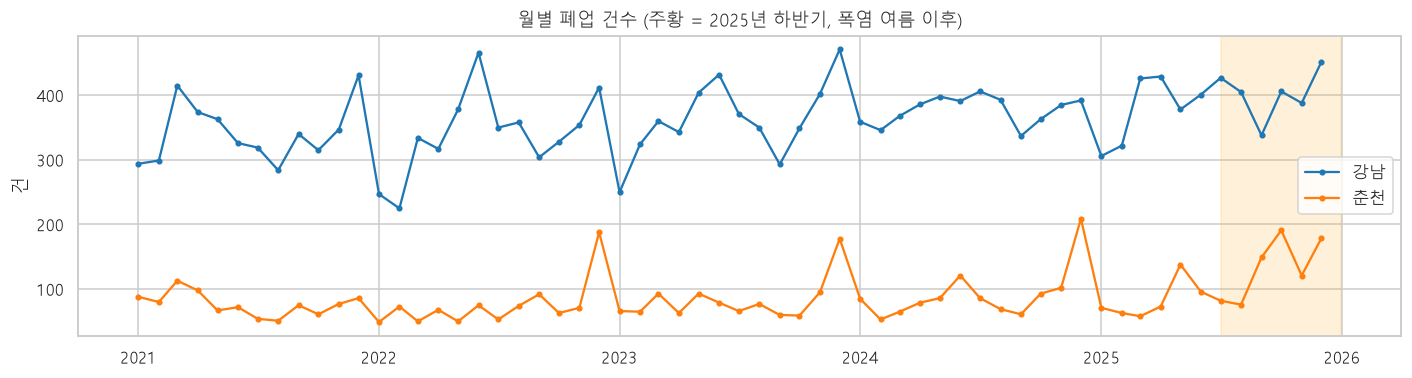

춘천 최근 월별 폐업 건수


,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
건,138,96,82,76,149,191,121,179


춘천 2021~2024년 월평균: 82건


In [4]:
closed = biz.dropna(subset=['close_date']).copy()      # 폐업일자가 있는 행만
closed['ym'] = closed['close_date'].dt.to_period('M')

MONTHS = pd.period_range('2021-01', '2025-12', freq='M')     # 최근 5년만 본다
monthly = closed.groupby(['region', 'ym']).size()

fig, ax = plt.subplots(figsize=(13, 3.6))
for r in REGIONS:
    s = monthly.loc[r].reindex(MONTHS, fill_value=0)
    ax.plot(s.index.to_timestamp(), s.values, 'o-', ms=3, color=REGION_COLOR[r], label=r)
ax.axvspan(pd.Timestamp('2025-07-01'), pd.Timestamp('2025-12-31'), color='orange', alpha=0.15)
ax.set(ylabel='건', title='월별 폐업 건수 (주황 = 2025년 하반기, 폭염 여름 이후)')
ax.legend()
plt.tight_layout(); plt.show()

print('춘천 최근 월별 폐업 건수')
display(monthly.loc['춘천'].reindex(pd.period_range('2025-05', '2025-12', freq='M')).rename('건').to_frame().T)
print(f"춘천 2021~2024년 월평균: {monthly.loc['춘천'].reindex(pd.period_range('2021-01', '2024-12', freq='M')).mean():.0f}건")

**눈에 띄는 것**: 춘천 2025년 **9월 149건, 10월 191건**이다. 2021 ~ 2024년 월평균이 80건 남짓이니 **2배가 넘는다.**
게다가 그 시점이 하필 **폭염 여름이 끝난 직후**다. 여기서 바로 "폭염 때문에 가게가 문을 닫았다"고 쓰고 싶어진다.

**하지만 아직 쓰면 안 된다.** 건수는 가게가 많은 지역에서 항상 크게 나오고, 계절에 따라서도 변한다. 먼저 비율로 바꿔 본다.

### 1-2. 건수를 비율로 바꾸기

**폐업률 = 그달 폐업 건수 / 그달 1일에 영업 중이던 사업장 수.**
원장에는 개업일과 폐업일이 다 있으므로, 과거 어느 시점이든 "그때 영업 중이던 가게"를 다시 세어 볼 수 있다.

,region,ym,active,close,rate
55,강남,2025-08,32980,405,12.28
56,강남,2025-09,32996,338,10.24
57,강남,2025-10,33059,406,12.28
58,강남,2025-11,33069,388,11.73
115,춘천,2025-08,12744,76,5.96
116,춘천,2025-09,12764,149,11.67
117,춘천,2025-10,12780,191,14.95
118,춘천,2025-11,12773,121,9.47


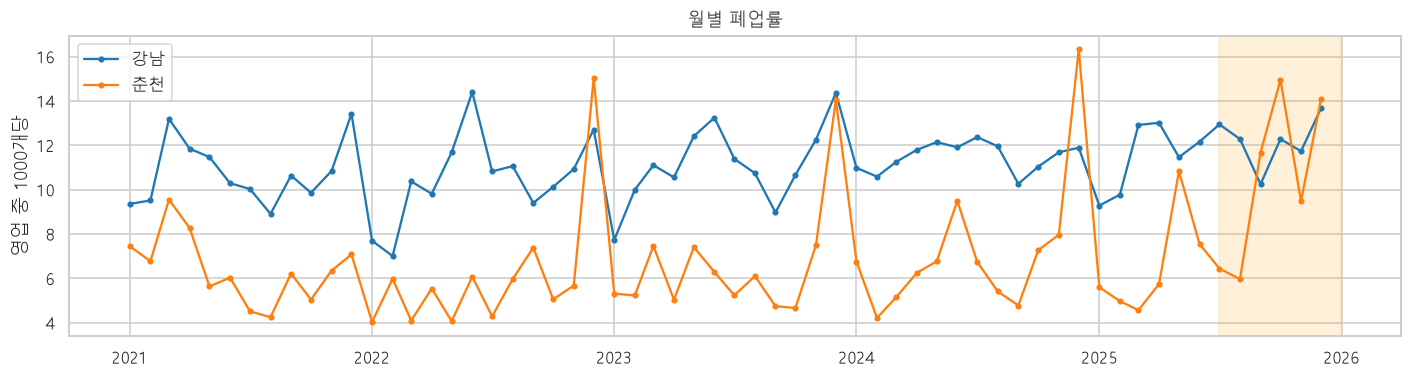

-> 비율로 바꿔도 춘천 2025년 9~10월 봉우리는 그대로 남아 있다. 가게 수 때문이 아니라는 뜻이다.


In [5]:
def 월별폐업률(df, months=MONTHS):
    # 지역 x 월 표를 만든다. active = 그달 1일에 영업 중이던 사업장 수
    rows = []
    for region, g in df.groupby('region'):
        op, cl = g['open_date'], g['close_date']
        cl_m = cl.dt.to_period('M')
        for m in months:
            start = m.to_timestamp()
            alive = (op < start) & (cl.isna() | (cl >= start))       # 이미 열었고 아직 안 닫은 것
            rows.append({'region': region, 'ym': m, 'active': int(alive.sum()),
                         'close': int((cl_m == m).sum())})
    p = pd.DataFrame(rows)
    p['rate'] = p['close'] / p['active'] * 1000       # 영업 중 1000개당 폐업 건수
    return p


panel = 월별폐업률(biz)
display(panel[panel['ym'].isin(pd.period_range('2025-08', '2025-11', freq='M'))])

fig, ax = plt.subplots(figsize=(13, 3.6))
for r in REGIONS:
    s = panel[panel['region'].eq(r)]
    ax.plot(s['ym'].dt.to_timestamp(), s['rate'], 'o-', ms=3, color=REGION_COLOR[r], label=r)
ax.axvspan(pd.Timestamp('2025-07-01'), pd.Timestamp('2025-12-31'), color='orange', alpha=0.15)
ax.set(ylabel='영업 중 1000개당', title='월별 폐업률')
ax.legend()
plt.tight_layout(); plt.show()
print('-> 비율로 바꿔도 춘천 2025년 9~10월 봉우리는 그대로 남아 있다. 가게 수 때문이 아니라는 뜻이다.')

### 1장 정리
- **본 것**: 월별 폐업 건수와 영업 중 대비 폐업률.
- **나온 것**: 춘천 2025년 9 ~ 10월이 평년의 2배 이상이다. 비율로 바꿔도 봉우리가 남는다.
- **다음**: 이 봉우리가 진짜 폐업인지 확인해야 한다. **닫힌 가게들이 얼마나 오래 영업했는지** 보면 단서가 나온다.

## 2. 이상한 것: 가게들이 너무 빨리 닫는다

폐업일에서 개업일을 빼면 그 가게가 **며칠 동안 영업했는지**가 나온다. 이 값의 분포를 보는 것은
"닫힌 가게가 어떤 가게였나"를 확인하는 가장 빠른 방법이다.

### 2-1. 영업 기간 분포

영업 기간 요약 (일)


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
강남,"94,827.00","1,906.00","2,285.00",0.00,286.00,"1,077.00","2,703.00","34,984.00"
춘천,"24,147.00","2,389.00","2,810.00",0.00,419.00,"1,395.00","3,360.00","38,487.00"


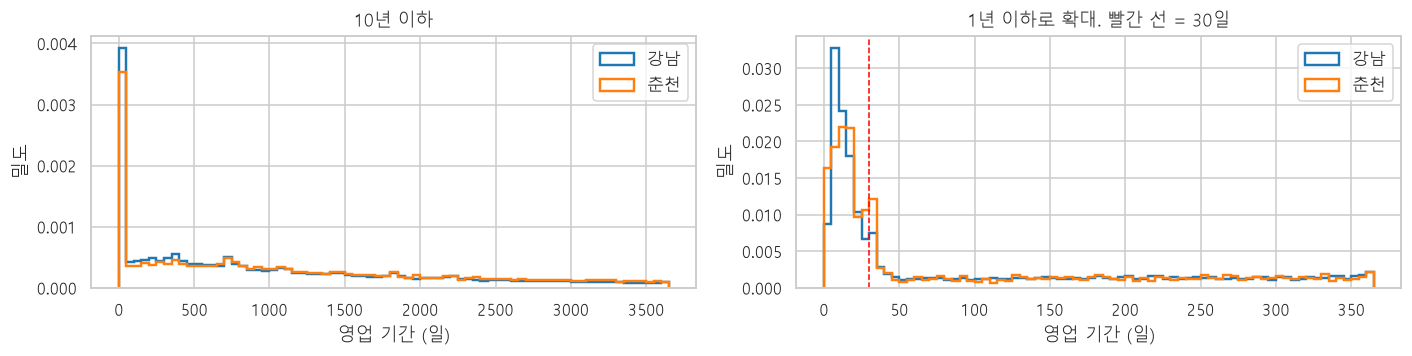

In [6]:
biz['dur'] = (biz['close_date'] - biz['open_date']).dt.days      # 영업 기간 (일)
closed = biz.dropna(subset=['close_date']).copy()

print('영업 기간 요약 (일)')
display(closed.groupby('region')['dur'].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for r in REGIONS:
    d = closed.loc[closed['region'].eq(r), 'dur']
    axes[0].hist(d[d <= 3650], bins=73, histtype='step', lw=1.6,     # 10년 이하, 50일 간격
                 color=REGION_COLOR[r], label=r, density=True)
    axes[1].hist(d[d <= 365], bins=73, histtype='step', lw=1.6,      # 1년 이하, 5일 간격
                 color=REGION_COLOR[r], label=r, density=True)
axes[0].set(xlabel='영업 기간 (일)', ylabel='밀도', title='10년 이하')
axes[1].axvline(30, ls='--', color='red', lw=1)
axes[1].set(xlabel='영업 기간 (일)', ylabel='밀도', title='1년 이하로 확대. 빨간 선 = 30일')
for ax in axes:
    ax.legend()
plt.tight_layout(); plt.show()

**이상한 점**: 오른쪽 그림에서 **0 ~ 30일 구간에 봉우리**가 솟아 있다. 그 뒤로는 완만하게 내려간다.

가게를 차리는 데는 보증금, 인테리어, 인허가가 든다. **한 달 만에 접는 일이 이렇게 흔할 수 없다.**
분포에 이런 뾰족한 덩어리가 있으면 대개 "다른 종류의 것이 섞여 들어왔다"는 신호다. 얼마나 되는지 센다.

### 2-2. 30일 이내 폐업이 얼마나 되나

전체 폐업 기록 중 30일 이내 비중


,건수,비중
region,,
강남,13819,0.15
춘천,2906,0.12


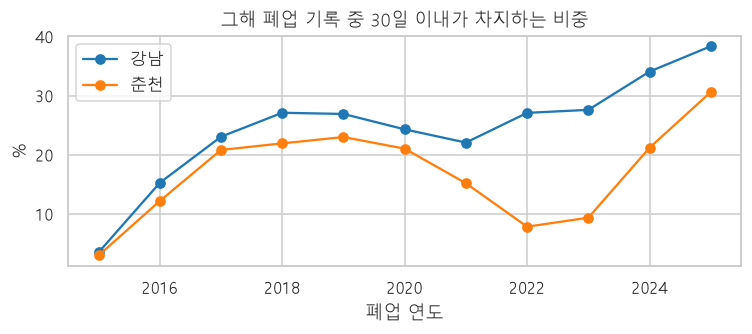

region,강남,춘천
연도,,
2021,22.10,15.20
2022,27.10,7.80
2023,27.60,9.40
2024,34.10,21.20
2025,38.30,30.60


In [7]:
closed['30일 이내'] = closed['dur'].between(0, 30)

print('전체 폐업 기록 중 30일 이내 비중')
display((closed.groupby('region')['30일 이내'].agg(['sum', 'mean'])
         .rename(columns={'sum': '건수', 'mean': '비중'})))

# 연도별로 보면 더 심각하다
closed['yr'] = closed['close_date'].dt.year
share = closed[closed['yr'].between(2015, 2025)].groupby(['region', 'yr'])['30일 이내'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 3.2))
for r in REGIONS:
    ax.plot(share.loc[r].index, share.loc[r].values, 'o-', color=REGION_COLOR[r], label=r)
ax.set(xlabel='폐업 연도', ylabel='%', title='그해 폐업 기록 중 30일 이내가 차지하는 비중')
ax.legend()
plt.tight_layout(); plt.show()
display(share.unstack(0).round(1).loc[2021:2025].rename_axis('연도'))

**나온 것**: 전체로 보면 강남 15%, 춘천 12%지만 **최근으로 올수록 커진다.**
2015년에는 3%였는데 **2025년에는 강남 38%, 춘천 31%** 다. 최근 폐업 기록의 3분의 1 이상이 30일 이내라는 뜻이다.

이 정도면 잡음이 아니라 **다른 종류의 기록이 대량으로 섞여 있는 것**이다. 정체를 밝혀야 한다.

### 2장 정리
- **본 것**: 영업 기간 분포와 30일 이내 비중.
- **나온 것**: 0 ~ 30일에 봉우리가 있고, 2025년 폐업 기록의 강남 38%, 춘천 31%가 여기 속한다. 해마다 커지는 중이다.
- **다음**: 이 기록들이 정확히 무엇인지 직접 열어 본다.

## 3. 정체 추적

정체를 밝히는 방법은 어렵지 않다. **직접 꺼내서 읽는 것**이다. 세 가지 각도로 본다.
언제(같은 날에 몰리나), 어디서(같은 주소인가), 무슨 이름인가.

### 3-1. 언제: 같은 날에 몰려 있나

In [8]:
short = closed[closed['30일 이내']]

# 2025년에 한 날짜로 가장 많이 몰린 덩어리를 지역마다 찾는다.
short_2025 = short[short['yr'].eq(2025)]
for r in REGIONS:
    day = short_2025[short_2025['region'].eq(r)]['close_date'].value_counts()
    print(f'[{r}] 2025년에 30일 이내 폐업이 가장 많았던 날')
    display(day.head(3).rename('건').to_frame().T)

[강남] 2025년에 30일 이내 폐업이 가장 많았던 날


close_date,2025-09-04,2025-02-27,2025-03-06
건,32,30,27


[춘천] 2025년에 30일 이내 폐업이 가장 많았던 날


close_date,2025-10-19,2025-10-26,2025-10-11
건,39,39,29


하루에 30 ~ 40건이 동시에 닫는다. 진짜 가게라면 있을 수 없는 일이다. 그날 무슨 일이 있었는지 직접 본다.

In [9]:
for r in REGIONS:
    day = short_2025[short_2025['region'].eq(r)]['close_date'].value_counts().idxmax()
    s = short_2025[short_2025['region'].eq(r) & short_2025['close_date'].eq(day)]
    print(f'[{r}] {day:%Y-%m-%d} 에 닫은 {len(s)}건')
    print(f'   업종: {s["industry"].value_counts().head(3).to_dict()}')
    print(f'   동  : {s["dong"].value_counts().head(3).to_dict()}')
    print(f'   개업일도 거의 같다: {s["open_date"].min():%m-%d} ~ {s["open_date"].max():%m-%d}')
    display(s[['name', 'industry', 'dong', 'addr_road', 'open_date', 'close_date']].head(5))

[강남] 2025-09-04 에 닫은 32건
   업종: {'일반음식점': 12, '휴게음식점': 9, '즉석판매제조가공업': 9}
   동  : {'개포2동': 12, '신사동': 7, '삼성1동': 4}
   개업일도 거의 같다: 08-14 ~ 09-02


,name,industry,dong,addr_road,open_date,close_date
3077,고깃집심서방본점(한시적),일반음식점,개포2동,"서울특별시 강남구 개포로 508, 소망빌딩 (개포동)",2025-09-01,2025-09-04
12486,만선호프(한시적),일반음식점,개포2동,"서울특별시 강남구 개포로 508, 강남개포시장 호프거리 일부호 (개포동)",2025-09-01,2025-09-04
21479,미술계(한시적),일반음식점,신사동,"서울특별시 강남구 압구정로 165, 현대백화점 압구정본점 지하1층 (압구정동)",2025-08-25,2025-09-04
31346,더드림(한시적),일반음식점,개포2동,"서울특별시 강남구 개포로 508, 소망빌딩 (개포동)",2025-09-02,2025-09-04
33216,벨리풀(한시적),일반음식점,신사동,"서울특별시 강남구 압구정로 165, 현대백화점본점 지하1층 (압구정동)",2025-08-25,2025-09-04


[춘천] 2025-10-19 에 닫은 39건
   업종: {'일반음식점': 24, '휴게음식점': 9, '즉석판매제조가공업': 6}
   동  : {'효자1동': 33, '강남동': 5, '소양동': 1}
   개업일도 거의 같다: 09-22 ~ 10-16


,name,industry,dong,addr_road,open_date,close_date
129610,일점오닭갈비,일반음식점,효자1동,None,2025-10-13,2025-10-19
129611,비와별닭갈비애막골점,일반음식점,효자1동,None,2025-10-14,2025-10-19
129612,우성닭갈비본점,일반음식점,효자1동,None,2025-10-14,2025-10-19
129613,춘천산닭 산속에닭갈비,일반음식점,효자1동,None,2025-10-13,2025-10-19
129614,감자아일랜드,일반음식점,효자1동,None,2025-10-14,2025-10-19


**보이는 것**: 폐업일이 하루로 똑같고 개업일도 몇 주 안에 몰려 있다. **다 같이 열었다가 같은 날 닫았다.**
춘천 39건은 대부분 효자1동(애막골) 닭갈비집이고, 강남 32건은 개포시장 호프거리와 현대백화점 압구정본점이다.
이름에 `(한시적)`이 붙은 것도 보인다. 주소를 세어 보면 확실해진다.

### 3-2. 어디서: 주소가 같은가

In [10]:
for r in REGIONS:
    top = (short[short['region'].eq(r)]['addr_road'].dropna()
           .str.split(',').str[0]                      # 건물 층, 호수를 떼고 건물 주소까지만
           .value_counts().head(5))
    print(f'[{r}] 30일 이내 폐업이 가장 많은 주소')
    for addr, n in top.items():
        print(f'   {n:>5,}건  {addr}')
    print()

[강남] 30일 이내 폐업이 가장 많은 주소
   2,353건  서울특별시 강남구 압구정로 165
   2,099건  서울특별시 강남구 영동대로 513
   1,830건  서울특별시 강남구 테헤란로 517
     986건  서울특별시 강남구 도곡로 401
     871건  서울특별시 강남구 압구정로 343

[춘천] 30일 이내 폐업이 가장 많은 주소
     333건  강원특별자치도 춘천시 경춘로 2353
     179건  강원특별자치도 춘천시 중앙로 105 (중앙로3가
      88건  강원특별자치도 춘천시 남산면 북한강변길 688
      85건  강원특별자치도 춘천시 동내면 공지로 80
      84건  강원특별자치도 춘천시 김유정로 1840



**정체가 드러난다.** 강남은 **현대백화점 압구정본점**(압구정로 165)과 **코엑스**(영동대로 513) 같은 건물 하나에 수천 건이 몰려 있다.
춘천도 특정 주소 몇 곳에 수백 건이 몰린다. **백화점 지하 식품관 팝업**과 **전시장, 축제장 부스**다.

진짜 가게라면 같은 건물에서 2천 개가 생겼다 사라질 수 없다. 마지막으로 이름을 확인한다.

### 3-3. 무슨 이름인가

In [11]:
KEYWORD = '한시적|행사|축제|팝업|임시'
closed['이름에 표시'] = closed['name'].fillna('').str.contains(KEYWORD)

print('이름에 한시적, 행사, 축제, 팝업, 임시가 들어간 건과 30일 이내 여부')
display(pd.crosstab(closed['30일 이내'], closed['이름에 표시'], normalize='index').round(3))
print(f"이름에 표시가 있는 건의 영업 기간 중앙값: {closed.loc[closed['이름에 표시'], 'dur'].median():.0f}일")
print()
print('실제 이름 예시 (30일 이내 폐업 중에서)')
print('  ', ', '.join(short.loc[short['name'].fillna('').str.contains('한시적'), 'name'].head(6)))

이름에 한시적, 행사, 축제, 팝업, 임시가 들어간 건과 30일 이내 여부


이름에 표시,False,True
30일 이내,,
False,0.99,0.01
True,0.51,0.49


이름에 표시가 있는 건의 영업 기간 중앙값: 13일

실제 이름 예시 (30일 이내 폐업 중에서)
   데바스테이트(한시적), 미라클브루어리(한시적), 카페여유(한시적), 포그(한시적), 리스카페(한시적), 서울브루어리 성수 탭룸(한시적)


**확인 끝**: 30일 이내로 닫힌 기록의 **절반**이 이름에 `한시적` 같은 표시를 달고 있다. 30일을 넘긴 기록에서는 1%도 안 된다.
이름에 표시가 있는 건의 영업 기간 중앙값은 **13일**이다.

즉 이 기록들은 **한시적 영업신고**다. 행사 기간에만 음식을 파는 부스가 개업 1건, 폐업 1건으로 기록된 것이다.
**가게가 망한 것이 아니라 행사가 끝난 것이다.**

> 이름 규칙이 30일 규칙보다 정확해 보이지만, 표기가 제각각이라(표시 없이 30일 이내인 것이 8천여 건) 실제로 거를 때는 **30일 규칙**을 쓴다.
> 표시 없는 8천여 건도 업종이 즉석판매제조가공업(행사 먹거리)에 몰려 있어 대부분 같은 성격으로 보인다.

### 3장 정리
- **본 것**: 같은 날 무더기 폐업, 주소 집중, 이름 표시.
- **나온 것**: 30일 이내 기록은 백화점 팝업과 전시장, 축제장의 **한시적 영업신고**다. 개업일도 폐업일도 같은 날에 몰려 있다.
- **다음**: 이것을 빼면 1장의 봉우리가 어떻게 되는지 확인한다.

## 4. 확인: 빼면 어떻게 되나

발견을 검증하는 방법은 간단하다. **빼 보고 1장의 그림이 달라지는지** 보는 것이다.
우리 가설이 맞다면 춘천 2025년 9 ~ 10월 봉우리는 사라져야 한다.

전체 165,219건에서 16,725건을 빼고 148,494건


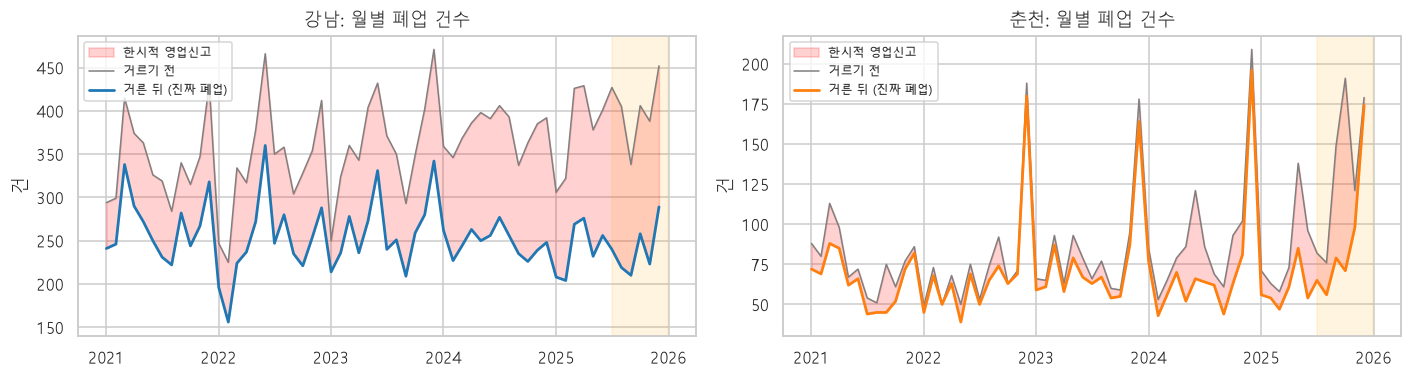

거르기 전        거른 뒤        한시적 비중 %      
region     강남   춘천     강남     춘천       강남    춘천
2025-07   427   82 240.00  65.00    44.00 21.00
2025-08   405   76 219.00  56.00    46.00 26.00
2025-09   338  149 210.00  79.00    38.00 47.00
2025-10   406  191 258.00  71.00    36.00 63.00
2025-11   388  121 223.00  98.00    43.00 19.00
2025-12   452  179 289.00 174.00    36.00  3.00

In [12]:
real = biz[~biz['dur'].between(0, 30)]                  # 30일 이내 기록을 뺀 표
print(f'전체 {len(biz):,}건에서 {int(biz["dur"].between(0, 30).sum()):,}건을 빼고 {len(real):,}건')

clean = real.dropna(subset=['close_date'])
clean_m = clean.groupby(['region', clean['close_date'].dt.to_period('M')]).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharex=True)
for ax, r in zip(axes, REGIONS):
    a = monthly.loc[r].reindex(MONTHS, fill_value=0)
    b = clean_m.loc[r].reindex(MONTHS, fill_value=0)
    x = a.index.to_timestamp()
    ax.fill_between(x, b.values, a.values, color='red', alpha=0.18, label='한시적 영업신고')
    ax.plot(x, a.values, color='gray', lw=1, label='거르기 전')
    ax.plot(x, b.values, color=REGION_COLOR[r], lw=1.8, label='거른 뒤 (진짜 폐업)')
    ax.axvspan(pd.Timestamp('2025-07-01'), pd.Timestamp('2025-12-31'), color='orange', alpha=0.12)
    ax.set(title=f'{r}: 월별 폐업 건수', ylabel='건')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

t = pd.DataFrame({'거르기 전': monthly, '거른 뒤': clean_m})
t['한시적 비중 %'] = ((1 - t['거른 뒤'] / t['거르기 전']) * 100).round(0)
display(t.loc[(slice(None), slice('2025-07', '2025-12')), :].unstack(0))

**확인됐다.** 춘천 2025년 9월 149건 -> **79건**, 10월 191건 -> **71건**으로 평년(60 ~ 90건) 수준이 된다.
10월 기록의 **63%** 가 한시적 영업신고였다. 1장에서 본 봉우리는 폭염이 아니라 **축제**였다.

강남은 봉우리가 없었지만 그래도 매달 기록의 **36 ~ 46%** 가 한시적 신고다. 봉우리가 없다고 안전한 것이 아니다.

## 5. 결론과 다음 할 일

**결론 한 줄**: 개폐업 원장으로 폐업을 셀 때는 **개업 30일 안에 닫힌 기록을 먼저 빼야 한다.**

만약 1장에서 멈추고 그대로 썼다면 보고서에 이렇게 적혔을 것이다.

> "2025년 폭염 여름이 끝난 뒤 춘천의 폐업이 평년의 2배 이상으로 급증했다."

그럴듯하고 **완전히 틀린** 문장이다. 실제로는 닭갈비 축제 노점이 문을 닫은 것이었다.

**이 노트북에서 배운 방법** (다른 자료에도 그대로 쓸 수 있다)
1. 건수를 세면 먼저 **비율로 바꿔** 본다. 크기 때문에 생긴 차이인지 거른다.
2. 이상한 봉우리가 보이면 **바로 해석하지 말고** 그 안에 무엇이 들어 있는지 본다.
3. 분포에 뾰족한 덩어리가 있으면 **다른 종류가 섞여 들어온 신호**로 의심한다.
4. 의심되면 **직접 몇 줄 꺼내서 읽는다.** 이름과 주소가 대개 답을 준다.
5. 발견했으면 **빼 보고 원래 그림이 달라지는지** 확인한다.

**다음**: 이 전처리를 전제로 한 본 분석은 [11번 노트북](11_bizreg_closure.ipynb)에서 한다.
거기서는 신고일 쏠림과 우측 절단 같은 남은 함정을 마저 확인하고, 코호트 폐업률로 "폭염 여름 뒤에 가게가 더 닫았나"에 답한다.